In [3]:
import cptac
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import os
import umap
import mofax as mofa
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mofapy2.run.entry_point import entry_point
from process_multiomics_for_mofa import read_csv_df,filter_genes, filter_genes_ppm, scale_df, make_long, print_non_numeric_values, read_csv_df
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'

In [5]:
#Read TFs
TF_df = pd.read_csv('data/TFs/TF_names_v_1.01.txt', header=None) #manually curated TFs proteins are obtained from https://humantfs.ccbr.utoronto.ca/
TF_df.shape
TF_list = TF_df[0].dropna().unique().tolist()
#print(TF_list)

In [7]:
#Extract Met CRC samples from the dataset
coad = cptac.Coad()
coad_clin = coad.get_clinical('mssm')
print(coad_clin.shape)
#coad_clin_met = coad_clin[
    #coad_clin['tumor_stage_pathological'].isin(["Stage III", "Stage IV"])
#]
#met_crc_sam = coad_clin_met.index
coad_clin_prim = coad_clin[
    coad_clin['tumor_stage_pathological'].isin(["Stage I", "Stage II"])
]
prim_crc_sam = coad_clin_prim.index
print(prim_crc_sam.shape)

(109, 124)
(54,)


In [9]:
#read rna
file_path = 'data/CPTAC_COAD_UNC_RNAseq_BCM_RSEM_UpperQuartile_log2.cct'
index_col = 0
coad_rna = read_csv_df(file_path)
#print(coad_rna.shape)
coad_rna = coad_rna.set_index('attrib_name')
coad_gene_tf_df = filter_genes(coad_rna, TF_list, axis=0)
coad_gene_tf_df.index = coad_gene_tf_df.index.astype(str) + '_rna' # rename after filtering
print(coad_gene_tf_df.shape)
prim = coad_gene_tf_df.columns.isin(prim_crc_sam)
met_crc_gene_tf = coad_gene_tf_df.loc[:, ~prim]
print(met_crc_gene_tf.head())

met_crc_gene_tf.to_csv('CPTAC_metCRC_UNC_RNAseq.csv', index=True)

(1072, 106)
             01CO001  01CO006  01CO014  01CO019  05CO002  05CO006  05CO007  \
attrib_name                                                                  
ADNP_rna     10.9233  11.1780  10.5098  11.7486  11.9465  11.4194  11.1630   
ADNP2_rna     9.2046   9.1137   9.8297   8.8611   8.6330   9.6600   9.6582   
AEBP1_rna     8.9129  10.0741   7.4429   8.9009  12.0293   9.9915  11.9103   
AEBP2_rna     9.5981   9.2336   8.7279   9.1749   9.5755   9.4115   9.6830   
AHCTF1_rna   11.1312  11.0189  11.7160  11.1978  11.0000  10.9454  10.7271   

             05CO014  05CO026  05CO032  ...  16CO002  16CO006  16CO011  \
attrib_name                             ...                              
ADNP_rna     12.1649  11.9629  10.5546  ...  12.0296  11.7474  11.4656   
ADNP2_rna     9.2143   8.7177  10.0084  ...   9.4676   9.5353   8.7313   
AEBP1_rna    10.1997  10.3542   9.5196  ...   9.3443  10.8478  10.9944   
AEBP2_rna     9.8963   9.8887   9.4450  ...   8.8826   9.8948   9.3923 

              01CO001   01CO006   01CO014   01CO019   05CO002   05CO006  \
attrib_name                                                               
ADNP_rna    -1.075655 -0.583495 -1.874666  0.519082  0.901487 -0.117035   
ADNP2_rna   -0.077724 -0.291795  1.394393 -0.886671 -1.423849  0.994748   
AEBP1_rna   -1.307445 -0.354786 -2.513446 -1.317290  1.249278 -0.422552   
AEBP2_rna    0.721509 -0.406161 -1.970669 -0.587764  0.651591  0.144216   
AHCTF1_rna   0.044894 -0.335216  2.024308  0.270320 -0.399188 -0.583997   

              05CO007   05CO014   05CO026   05CO032  ...   16CO002   16CO006  \
attrib_name                                          ...                       
ADNP_rna    -0.612480  1.323504  0.933177 -1.788099  ...  1.062062  0.516763   
ADNP2_rna    0.990509 -0.054881 -1.224380  1.815234  ...  0.541644  0.701078   
AEBP1_rna    1.151649 -0.251743 -0.124989 -0.809703  ... -0.953520  0.279965   
AEBP2_rna    0.984168  1.644064  1.620552  0.247857  ... -1.492066  1.6394

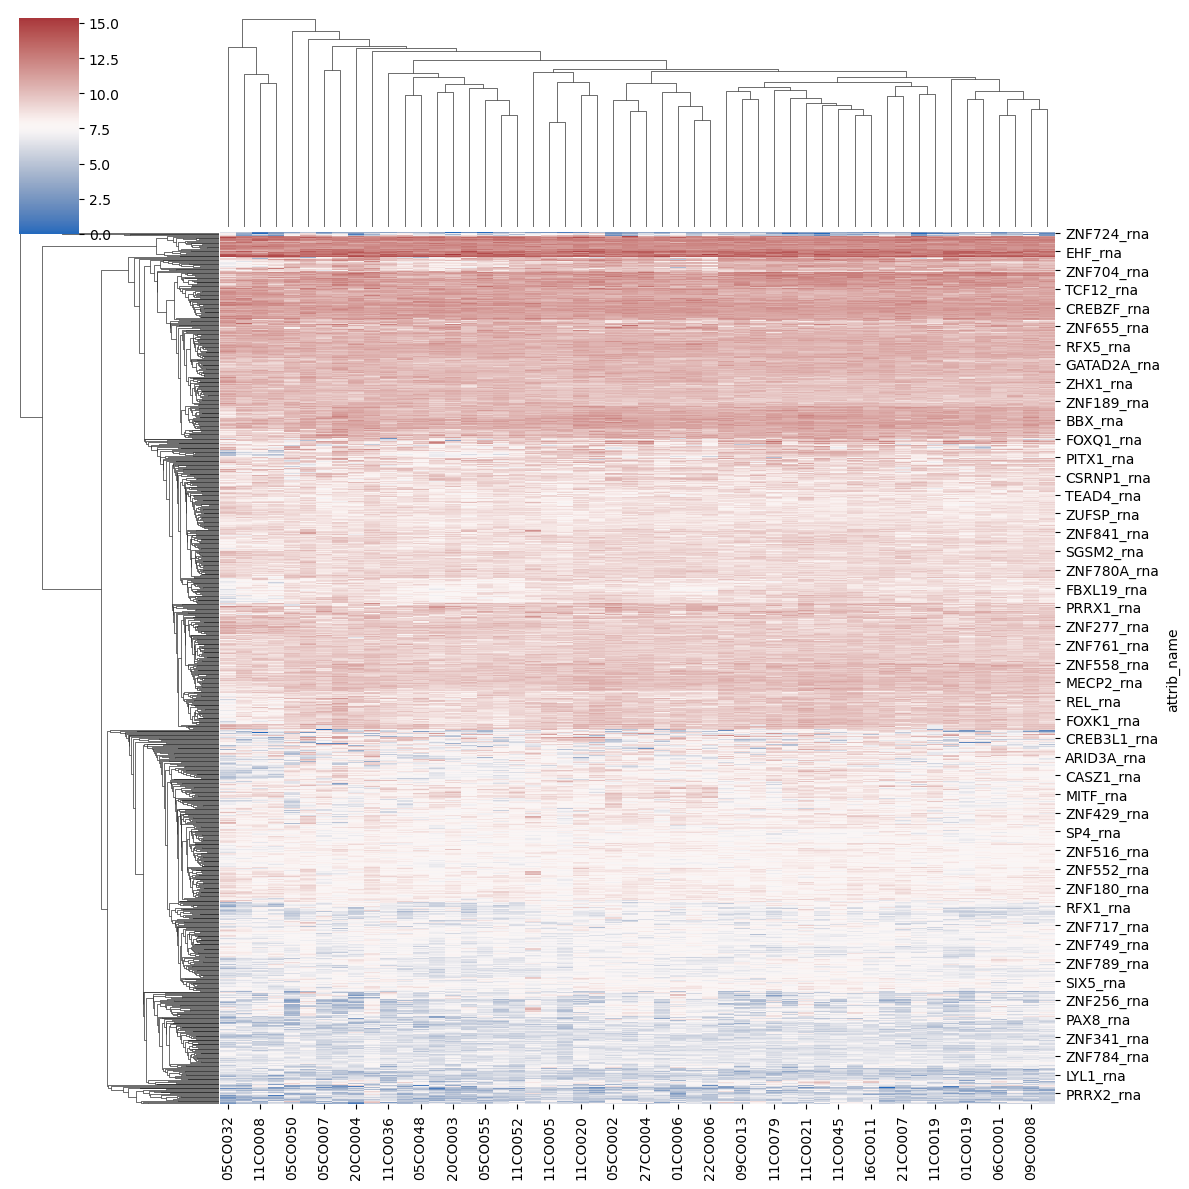

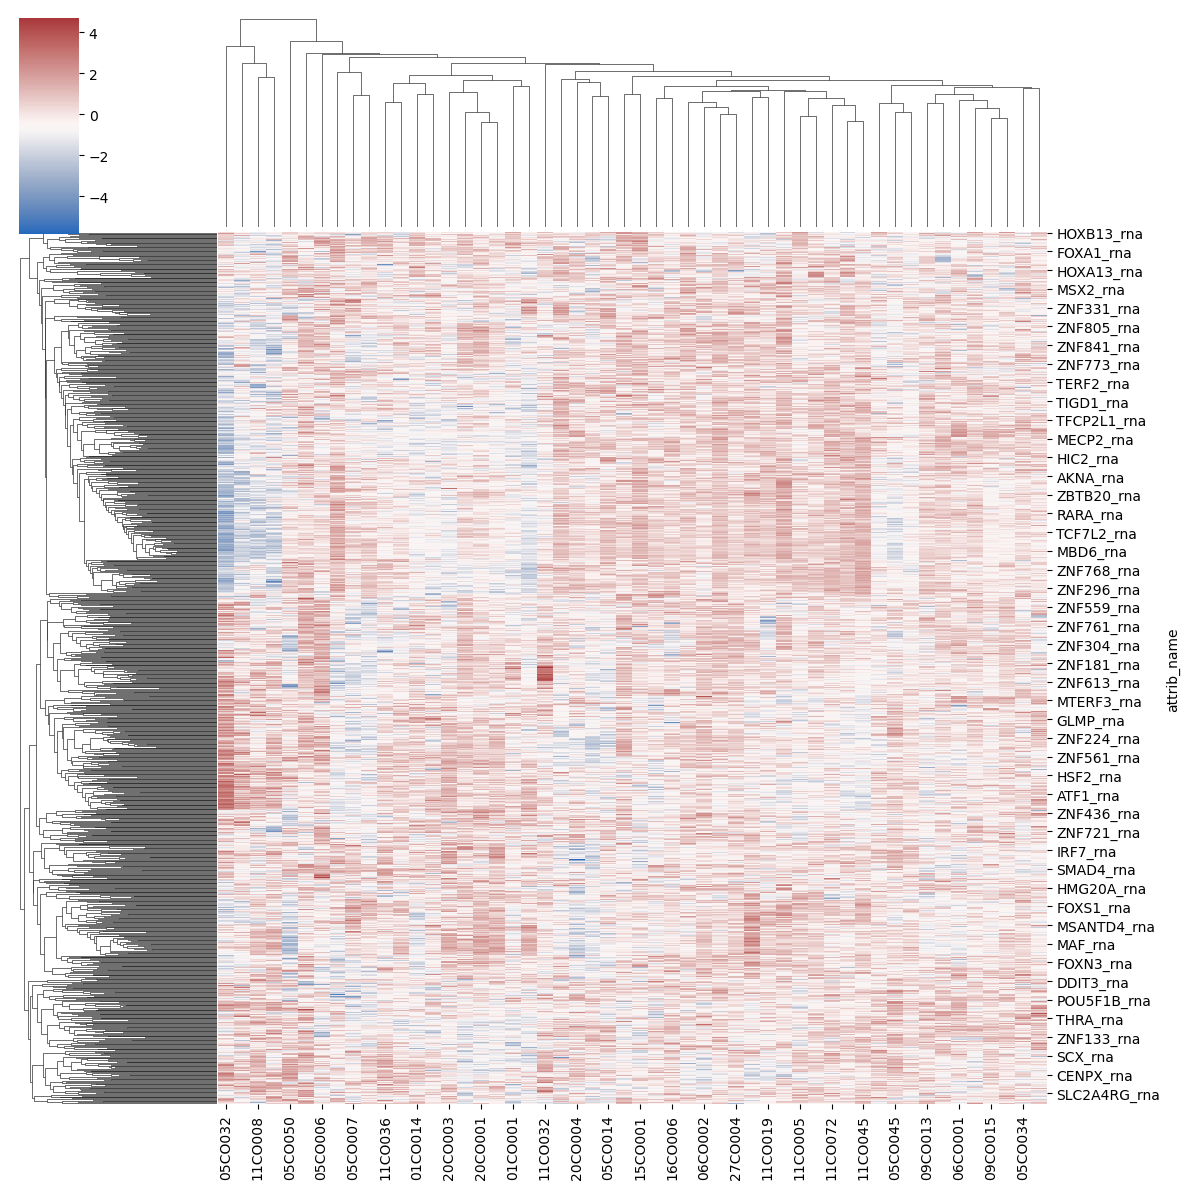

In [11]:
# Step 2: Scale and plot
mdf = met_crc_gene_tf

# Step 3: (Optional) Standardize expression across samples
scaler = StandardScaler()
met_crc_scaled = scale_df(met_crc_gene_tf, axis =1)
print(met_crc_scaled.head())
# Step 4: Plot heatmap
sns.clustermap(mdf, cmap='vlag', figsize=(12, 12))
#plt.show()
sns.clustermap(met_crc_scaled, cmap='vlag', figsize=(12, 12))
#plt.show()

In [13]:
#Make RNA df (long format)
met_crc_tf_rna = make_long(met_crc_scaled, "RNA")
print(met_crc_tf_rna.head())

  attrib_name Patient_ID     Value view
0    ADNP_rna    01CO001 -1.075655  RNA
1   ADNP2_rna    01CO001 -0.077724  RNA
2   AEBP1_rna    01CO001 -1.307445  RNA
3   AEBP2_rna    01CO001  0.721509  RNA
4  AHCTF1_rna    01CO001  0.044894  RNA


In [15]:
#read and make protein df
#Read Tumor data
fp_t = 'data/data/CPTAC_COAD_PNNL_Proteome_Gene_Tumor_TMT_UnsharedLogRatio.cct'
index_col = 0
coad_prot_t = read_csv_df(fp_t)
#coad_prot_t.head()        # Show first 5 rows
#Filter TFs
coad_prot_t = coad_prot_t.set_index('attrib_name')
coad_prot_t_tf_df = filter_genes(coad_prot_t, TF_list, axis=0)
coad_prot_t_tf_df.index = coad_prot_t_tf_df.index.astype(str) + '_protein'
print(coad_prot_t_tf_df.head())

prim = coad_prot_t_tf_df.columns.isin(prim_crc_sam)
met_crc_protein_tf = coad_prot_t_tf_df.loc[:, ~prim]
met_crc_protein_tf.to_csv('CPTAC_metCRC_PNNL_proteome_TMT_UnsharedLogRatio.csv', index=True)

#Read Normal data
fp_n = 'data/CPTAC_COAD_PNNL_Proteome_Gene_Normal_TMT_UnsharedLogRatio.cct'
index_col = 0
coad_prot_n = read_csv_df(fp_n)
#coad_prot_n.head()        # Show first 5 rows
#coad_rna.columns       # List column names
#coad_rna.shape         # (rows, columns)
#Filter TFs
coad_prot_n = coad_prot_n.set_index('attrib_name')
coad_prot_n_tf_df = filter_genes(coad_prot_n, TF_list, axis=0)
coad_prot_n_tf_df.index = coad_prot_n_tf_df.index.astype(str) + '_protein' # rename after filtering
#print(coad_prot_n_tf_df.shape)

# Standardize expression a
#concatenate 
coad_tf_protein = pd.concat([coad_prot_n_tf_df, met_crc_protein_tf], axis=1) # tumor is filtered for metCRC

met_crc_protein_scaled = scale_df(coad_tf_protein, axis =1)
#print(met_crc_protein_scaled.head())
print(met_crc_protein_scaled.shape)

#Make Long dfs
met_crc_lprotein=()
met_crc_lprotein = make_long(met_crc_protein_scaled, "protein")
print(met_crc_lprotein.head())

                01CO005  01CO006  01CO008  01CO013  01CO014  01CO015  01CO019  \
attrib_name                                                                     
ADNP_protein     0.2940  -0.2710  -0.0535    0.364   -0.176   0.6390    0.322   
AEBP1_protein   -0.2690  -1.4000  -0.9600   -0.732   -0.670  -0.3860   -0.239   
AHCTF1_protein   0.1040  -0.1610   0.1700    0.407    0.354   0.1200    0.137   
AHR_protein         NaN   0.0610  -0.0002   -0.087    0.607  -0.0893   -0.381   
AKAP8_protein    0.0053  -0.0819   0.3000    0.156   -0.104   0.0694    0.105   

                01CO022  05CO002  05CO003  ...  20CO001  20CO003  20CO004  \
attrib_name                                ...                              
ADNP_protein      0.143    0.533   0.3510  ...   0.0156  -0.2870    0.467   
AEBP1_protein    -0.754   -0.235   1.1100  ...   0.2630   0.4380   -0.251   
AHCTF1_protein    0.402    0.239  -0.0615  ...   0.2560  -0.1910    0.159   
AHR_protein       0.387    0.100   0.4860  ... 

In [17]:
#read and make ppm df
fpm_t = 'data/CPTAC_COAD_multiOmics/CPTAC_COAD_PNNL_Phosphoproteome_Tumor_LogRatio.cct'
index_col = 0
coad_ppm_t = read_csv_df(fpm_t)
#print(coad_ppm_t.columns)
coad_ppm_t = coad_ppm_t.set_index('attrib_name')
coad_ppm_t.index = coad_ppm_t.index.str.split('__').str[0]
coad_ppm_t["Gene"] = coad_ppm_t.index.str.split('_').str[0]
#print(coad_ppm_t.head())
coad_ppm_t_tf_df = filter_genes_ppm(coad_ppm_t, TF_list, axis=0)
coad_ppm_t_tf_df = coad_ppm_t_tf_df.dropna(axis=1, how='all')
coad_ppm_t_tf_df.index = coad_ppm_t_tf_df.index.astype(str) + '_pp'
print(coad_ppm_t_tf_df.shape)
prim2 = coad_ppm_t_tf_df.columns.isin(prim_crc_sam)
met_crc_ppm = coad_ppm_t_tf_df.loc[:, ~prim2]

fpm_n = '/Users/sathya/work/Data/TFactivity/CPTACdatasets/CPTAC_COAD_multiOmics/CPTAC_COAD_PNNL_Phosphoproteome_Normal_logRatio.cct'
index_col = 0
coad_ppm_n = read_csv_df(fpm_n)
# Change colnames of normal samples to 
coad_ppm_n.columns = [
    col if i == 0 else f"{col}N"
    for i, col in enumerate(coad_ppm_n.columns)
]
#print(coad_ppm_n.head())
coad_ppm_n = coad_ppm_n.set_index('attrib_name')
coad_ppm_n.index = coad_ppm_n.index.str.split('__').str[0]
coad_ppm_n["Gene"] = coad_ppm_n.index.str.split('_').str[0]
#print(coad_ppm_n.head())
coad_ppm_n_tf_df = filter_genes_ppm(coad_ppm_n, TF_list, axis=0)
coad_ppm_n_tf_df = coad_ppm_n_tf_df.dropna(axis=1, how='all')
coad_ppm_n_tf_df.index = coad_ppm_n_tf_df.index.astype(str) + '_pp'
print(coad_ppm_n_tf_df.shape)

#concatenate before making long
coad_tf_ppm = pd.concat([coad_ppm_n_tf_df, met_crc_ppm], axis =1)

#Filter met crc

met_crc_ppm_scaled = scale_df(coad_tf_ppm, axis =1)

met_crc_lppm = make_long(met_crc_ppm_scaled, "ppm")
print(met_crc_lppm.head())

(2263, 97)
(2263, 100)
    attrib_name Patient_ID     Value view
0  E2F8_S102_pp   01CO001N       NaN  ppm
1  E2F8_S413_pp   01CO001N       NaN  ppm
2  E2F8_S417_pp   01CO001N       NaN  ppm
3  E2F8_S664_pp   01CO001N       NaN  ppm
4   E2F8_S71_pp   01CO001N -0.371114  ppm


In [19]:
def print_non_numeric_values(df, column):
    coerced = pd.to_numeric(df[column], errors='coerce')
    non_numeric = df.loc[coerced.isna() & df[column].notna(), column]
    print(non_numeric.unique())

# Example usage:
print_non_numeric_values(met_crc_lppm, 'Value')

[]


In [21]:
#Merge all omic df to single input for MOFA
#combined_met_crc = pd.concat([coad_tf_rna, coad_tf_t_protein, coad_tf_n_protein, coad_tf_t_ppm, coad_tf_n_ppm], axis=0)
combined_met_crc = pd.concat([met_crc_tf_rna, met_crc_lprotein, met_crc_lppm], axis=0)

#Drop NA
combined_met_crc = combined_met_crc.dropna(subset=['Value'])
print(combined_met_crc.shape)
combined_met_crc = combined_met_crc.rename(columns={'Patient_ID': 'sample', 'attrib_name': 'feature', 'Value':'value', 'View':'view'})
combined_met_crc['group'] = 'groupA'
combined_met_crc = combined_met_crc.drop_duplicates(subset=["group", "view", "feature", "sample"])
combined_met_crc = combined_met_crc.dropna(subset=['value'])
print(combined_met_crc.head())


(200708, 4)
      feature   sample     value view   group
0    ADNP_rna  01CO001 -1.075655  RNA  groupA
1   ADNP2_rna  01CO001 -0.077724  RNA  groupA
2   AEBP1_rna  01CO001 -1.307445  RNA  groupA
3   AEBP2_rna  01CO001  0.721509  RNA  groupA
4  AHCTF1_rna  01CO001  0.044894  RNA  groupA


In [23]:
## get how many features in your data
## if you only have two datasets, please skip the last row
D = [len(combined_met_crc[combined_met_crc["view"] == "RNA"]["feature"].value_counts()), 
    len(combined_met_crc[combined_met_crc["view"] == "protein"]["feature"].value_counts()),
    len(combined_met_crc[combined_met_crc["view"] == "ppm"]["feature"].value_counts())]  ## please check if you have phospho data

M = 3         # Number of views, please check your data
K = 10        # Number of factors you want to check
N = len(combined_met_crc[combined_met_crc["view"] == "ppm"]["sample"].value_counts())    # Number of samples per group
G = 1         # Number of groups, please set as 1
print(D)
print(N)

[1072, 275, 2262]
148


In [25]:
ent = entry_point()


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        


In [ ]:
ent.set_data_options(
    scale_groups = False, 
    scale_views = False
)
ent.set_data_df(combined_met_crc, likelihoods = ["gaussian", "gaussian","gaussian"])

In [ ]:
print(combined_met_crc['value'].apply(type).value_counts())
invalid_rows = combined_met_crc[pd.to_numeric(combined_met_crc['value'], errors='coerce').isna()]
print(invalid_rows.head())

In [ ]:
ent.set_model_options(
    factors = 10, 
    spikeslab_weights = True, 
    ard_factors = True,
    ard_weights = True
)

In [ ]:
#Set sample metadata
#ent.set_sample_metadata(metadata)
#ent.sample_metadata = metadata

In [ ]:
ent.set_train_options(
    iter = 1000, 
    convergence_mode = "medium", 
    startELBO = 1, 
    freqELBO = 1, 
    dropR2 = 0.001, 
    gpu_mode = False, 
    verbose = False, 
    seed = 42
)

In [ ]:
ent.build()
ent.run()

In [ ]:
path='/Users/sathya/work/Data/TFactivity/CRC-BLCA/metcrc/'
combined_met_crc_out = os.path.join(path, "combined_met_crc_view.hdf5")

ent.save(outfile=combined_met_crc_out)

In [ ]:
met_crc_out = mofa.mofa_model("/Users/sathya/work/Data/TFactivity/CRC-BLCA/metcrc/combined_met_crc_view.hdf5")
met_crc_out

In [ ]:
# Step 1: Metadata
metadata = pd.read_csv("/Users/sathya/work/Data/TFactivity/CPTACdatasets/CPTAC_COAD_multiOmics/CPTAC_COAD_clinical_selected.csv") 
#print(coad_out.get_samples())
samples = met_crc_out.get_samples()['sample']  # returns a dict: {group_name: [sample_ids]}
#print(samples.head())
# Step 2: UMAP embedding
factors_df = met_crc_out.get_factors()  # returns a dict with group names
embedding = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(factors_df)

umap_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
umap_df["Patient_ID"] = samples # list of sample IDs from MOFA
merged_df = umap_df.merge(metadata, on="Patient_ID", how="left")
#print(merged_df.shape)

# Step 3: Plot
plt.figure(figsize=(8,8))
sns.scatterplot(data=merged_df, x="UMAP1", y="UMAP2", hue="tumor_stage_pathological", palette="tab10", s=100)
plt.title("UMAP of MOFA Factors Colored by Clinical Stage")
plt.tight_layout()
#plt.show()

In [ ]:
met_crc_out.shape
#print(met_crc_out.metadata)

In [ ]:
met_crc_out.get_cells().head()

In [ ]:
met_crc_out.metadata.shape

In [ ]:
met_crc_out.get_factors(factors=range(3), df=True).head()